# Graph Neural Network with Graph Attention

This notebook demonstrates how to use Graph Neural Networks (GNNs) with graph attention for a robot navigation problem. The goal is to predict a "risk level" based on the robot's trajectory and obstacle configurations.


## 1. Introduction
This section provides an overview of the problem and objectives.

## 2. Dataset Preparation
- Generate robot and obstacle data.
- Compute risk levels based on time to collision.
- Prepare the dataset for use in a GNN.

## 3. Graph Representation
- Define nodes, edges, and features.
- Construct the graph representation for the problem.

## 4. Graph Neural Network (GNN) Design
- Implement a GNN using Graph Attention Network (GAT) layers.
- Add a Multi-Layer Perceptron (MLP) for final prediction.

## 5. Training the GNN
- Define the training process, including loss function and optimizer.
- Train the GNN on the dataset to predict risk levels.

## 6. Evaluation and Visualization
- Evaluate the model on a validation set.
- Visualize predictions for specific examples.

### Step 2: Dataset Preparation

We will:
- Randomly generate positions and radii for obstacles.
- Sample the robot's position, angle, and velocity.
- Compute the edges between the robot and obstacles based on distance.
- Calculate the risk level as the ground truth by forward simulating the robot's motion until it collides with an obstacle.

In [1]:
!which python

/home/robin/anaconda3/envs/evidential/bin/python


In [2]:
!python -m pip install torch torch_geometric networkx torch_scatter
!python -m pip install numpy pandas matplotlib scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.2 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.5/184.5 kB 54.5 MB/s eta 0:00:00


In [3]:
import torch
import numpy as np

# Helper function to calculate time to collision

ROBOT_RADIUS = 0.05
MAX_RISK = 2.0

In [5]:

def compute_time_to_collision(robot, obstacles):
    """
    Computes the time to collision between a robot and obstacles.

    Args:
        robot: A list [x, y, vx, vy] representing the robot's position and velocity.
        obstacles: A list of obstacles, each [ox, oy, r] with position and radius.

    Returns:
        Minimum time to collision or a large value if no collision occurs.
    """
    x, y, vx, vy = robot
    times = []

    for obs in obstacles:
        ox, oy, r = obs
        dx, dy = ox - x, oy - y
        d = np.sqrt(dx**2 + dy**2)

        r += ROBOT_RADIUS

        # Check if already in collision
        if d <= r:
            times.append(0)
            continue

        # Normalize velocity vector
        velocity_magnitude = np.linalg.norm([vx, vy])
        if velocity_magnitude == 0:
            continue  # Skip if robot is stationary

        vx_norm, vy_norm = vx / velocity_magnitude, vy / velocity_magnitude
        rel_pos = np.array([dx, dy])
        # Projection onto velocity vector
        proj = np.dot(rel_pos, np.array([vx_norm, vy_norm]))

        if proj <= 0:
            # Obstacle is behind or perpendicular to the robot's motion
            continue

        # Compute the closest distance to the obstacle along the motion path
        closest_dist = np.sqrt(d**2 - proj**2)
        if closest_dist <= r:
            # Compute the time to collision
            t = (proj - r) / velocity_magnitude
            t = max(t, 0)
            times.append(t)

    # If no collision is possible, return a very large time
    return min(times) if times else MAX_RISK
# Generate random dataset

In [6]:

def generate_dataset(num_samples):
    dataset = []
    while len(dataset) < num_samples:
        # Robot parameters
        robot = {
            'x': np.random.uniform(-0.1, 0.1),
            'y': np.random.uniform(-0.1, 0.1),
            'theta': np.random.uniform(0.05 * np.pi, 0.45 * np.pi),
            'radius': ROBOT_RADIUS
        }
        robot['cos_theta'] = np.cos(robot['theta'])
        robot['sin_theta'] = np.sin(robot['theta'])

        # Obstacles
        obstacles = []
        for _ in range(np.random.randint(3, 10)):
            obs = {
                'x': np.random.uniform(0.1, 1.4),
                'y': np.random.uniform(0.1, 1.4),
                'radius': np.random.uniform(0.1, 0.3)
            }
            obstacles.append([obs['x'], obs['y'], obs['radius']])

        # Robot state and velocity
        robot_state = [
            robot['x'],
            robot['y'],
            robot['cos_theta'] * 1.0,  # velocity in x direction (vx)
            robot['sin_theta'] * 1.0   # velocity in y direction (vy)
        ]

        # Compute risk (time to collision)
        risk = compute_time_to_collision(robot_state, obstacles)

        if risk == 0.0:
            continue

        # Append to dataset
        dataset.append(
            {'robot': robot_state, 'obstacles': obstacles, 'risk': risk})

    return dataset


# Create dataset
# dataset = generate_dataset(100000)
dataset = generate_dataset(3000)
print("Sample dataset:", dataset[0])

Sample dataset: {'robot': [-0.04615392515624892, 0.018242389116730123, 0.809184852512482, 0.5875541459851619], 'obstacles': [[1.2778411492643917, 1.0921825895493718, 0.1398845590252803], [0.2964976471617221, 1.0629051502587672, 0.11299452108447439], [1.3597685637652037, 0.26963653303544555, 0.2220313286091281], [1.0898427948728677, 0.17482155040477768, 0.2838492453883621], [0.24073093453723826, 1.1277248654753964, 0.28080020468094036], [0.15517887691888374, 0.7918037108723495, 0.15501668126053034], [0.6703684729852009, 1.1858000325453992, 0.28530615399084114]], 'risk': 1.5124702173013727}


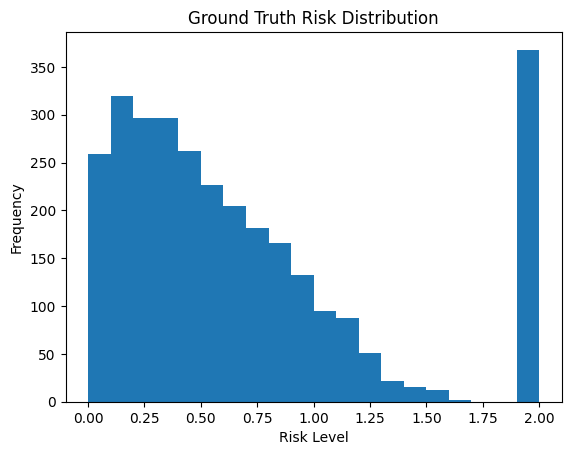

In [7]:
import matplotlib.pyplot as plt

risks = [d['risk'] for d in dataset]
plt.hist(risks, bins=20)
plt.title("Ground Truth Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Frequency")
plt.show()

In [8]:
import pandas as pd

# Convert dataset into Pandas DataFrame
data_records = []
for sample in dataset:
    num_obstacles = len(sample['obstacles'])
    record = {
        "robot_x": sample['robot'][0],
        "robot_y": sample['robot'][1],
        "robot_cos_theta": sample['robot'][2],
        "robot_sin_theta": sample['robot'][3],
        "num_obstacles": num_obstacles,
        "risk": sample['risk']
    }
    data_records.append(record)

df = pd.DataFrame(data_records)

# Display statistics
statistics = df.describe()
print(statistics)

           robot_x      robot_y  robot_cos_theta  robot_sin_theta  \
count  3000.000000  3000.000000      3000.000000      3000.000000   
mean     -0.000637    -0.001054         0.655081         0.666964   
std       0.057603     0.057164         0.250886         0.251248   
min      -0.099895    -0.099934         0.156653         0.156776   
25%      -0.051083    -0.050147         0.443834         0.458305   
50%       0.000434    -0.002419         0.698187         0.715915   
75%       0.048196     0.046838         0.888795         0.896109   
max       0.099834     0.099995         0.987634         0.987654   

       num_obstacles         risk  
count    3000.000000  3000.000000  
mean        5.955667     0.697242  
std         1.972730     0.586474  
min         3.000000     0.000683  
25%         4.000000     0.257501  
50%         6.000000     0.534517  
75%         8.000000     0.922421  
max         9.000000     2.000000  


risk:  0.41114131049149893
num_obstacles:  7
robot:  [0.09806558690874606, -0.03847527019504811, 0.9467283940084895, 0.32203314732820026]


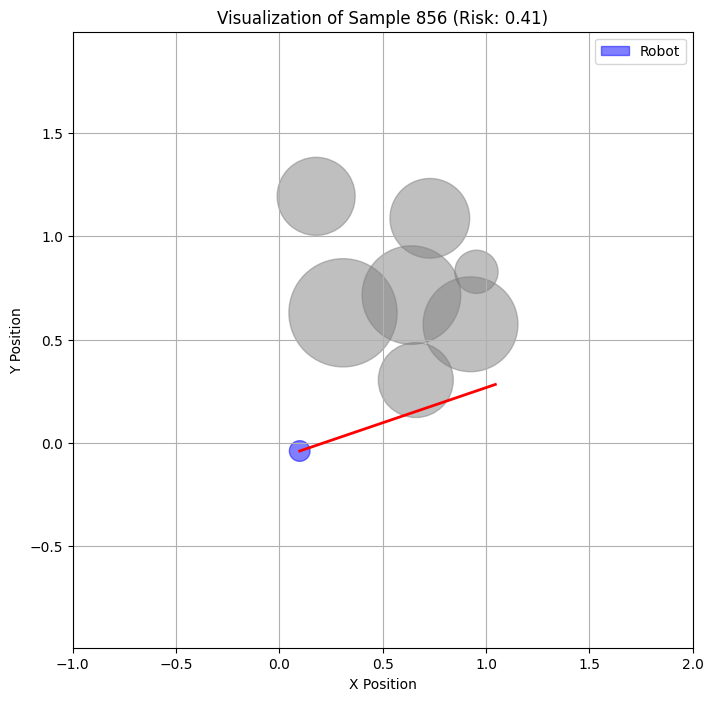

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle


def visualize_sample_with_heading(sample_idx=-1):
    """
    Visualizes the robot, its yaw angle heading, and obstacles for a specific dataset sample.
    """
    if sample_idx == -1:
        sample_idx = np.random.randint(0, len(dataset))
    sample = dataset[sample_idx]
    robot = sample['robot']
    obstacles = sample['obstacles']
    print("risk: ", sample['risk'])
    print("num_obstacles: ", len(obstacles))
    print("robot: ", robot)

    fig, ax = plt.subplots(figsize=(8, 8))

    # Draw the robot (blue circle)
    robot_circle = Circle((robot[0], robot[1]), ROBOT_RADIUS,
                          color='blue', alpha=0.5, label="Robot")
    ax.add_patch(robot_circle)

    # Draw the robot's yaw angle heading (red line)
    yaw_length = 1.0  # Length of the heading line
    yaw_end_x = robot[0] + yaw_length * robot[2]  # x + cos(theta)
    yaw_end_y = robot[1] + yaw_length * robot[3]  # y + sin(theta)
    ax.plot([robot[0], yaw_end_x], [robot[1], yaw_end_y],
            color='red', linewidth=2, label="Yaw Heading")

    # Draw obstacles (gray circles)
    for obs in obstacles:
        obs_circle = Circle((obs[0], obs[1]), obs[2],
                            color='gray', alpha=0.5, label="Obstacle")
        ax.add_patch(obs_circle)

    # Add plot details
    ax.set_xlim(-1, 2)
    ax.set_ylim(-1, 2)
    ax.set_aspect('equal', adjustable='datalim')
    plt.title(
        f"Visualization of Sample {sample_idx} (Risk: {sample['risk']:.2f})")
    plt.xlabel("X Position")
    plt.ylabel("Y Position")
    plt.grid(True)
    plt.legend(handles=[robot_circle], loc="upper right")
    plt.show()


# Visualize the first sample with yaw heading
visualize_sample_with_heading()

## 3. Graph Representation

In this section, we define the graph structure for the problem:
- **Nodes**: Represent the robot and obstacles.
  - The robot's node includes its position `(x, y)` and heading `(cos(theta), sin(theta))`.
  - Each obstacle node includes its position `(x, y)` and radius.
- **Edges**: Represent the connections between the robot and obstacles.
  - Each edge includes the Euclidean distance between the robot and the obstacle.
  - Obstacle-to-obstacle edges are ignored for simplicity.
- **Features**:
  - Node features for the robot: `[x, y, cos(theta), sin(theta)]`.
  - Node features for obstacles: `[x, y, radius]`.
  - Edge features: `[distance]`.

We use the PyTorch Geometric library to represent and process the graph. Each graph will have:
- Node features matrix `x`.
- Edge index tensor `edge_index` (specifies connectivity).
- Edge features matrix `edge_attr`.

In [10]:
import torch
from torch_geometric.data import Data
from itertools import combinations


def create_graph(robot, obstacles, risk):
    """
    Constructs a graph representation for the given robot, obstacles, and dynamics.

    Args:
        robot: A list [x, y, vx, vy] representing the robot's position and velocity.
        obstacles: A list of obstacles, each [x, y, radius].

    Returns:
        A PyTorch Geometric Data object representing the graph.
    """

    # Number of nodes
    num_obstacles = len(obstacles)
    num_nodes = num_obstacles + 1  # Robot + obstacles

    # One-hot encoding for node features
    robot_node_features = [1, 0, 0]  # [robot_class, obs_class, goal_class]
    obstacle_node_features = [0, 1, 0]  # [robot_class, obs_class, goal_class]

    # Construct node features
    node_features = [robot_node_features]  # Start with robot
    for _ in range(num_obstacles):
        node_features.append(obstacle_node_features)
    node_features = torch.tensor(
        node_features, dtype=torch.float)  # Shape: [N, 3]

    # Node positions
    robot_pos = torch.tensor(robot[:2], dtype=torch.float)  # [x, y]
    obstacle_positions = torch.tensor(
        [obs[:2] for obs in obstacles], dtype=torch.float)  # [N_obstacles, 2]

    # Node radii
    robot_radius = ROBOT_RADIUS
    obstacle_radii = torch.tensor(
        [obs[2] for obs in obstacles], dtype=torch.float)  # [N_obstacles]

    # Relative positions for edges
    all_positions = torch.cat(
        [robot_pos.unsqueeze(0), obstacle_positions], dim=0)  # [N, 2]
    # print(all_positions)
    # print("all_positions.shape: ", all_positions.shape)
    # TODO: be careful with the sign
    relative_positions = - all_positions.unsqueeze(
        1) + all_positions.unsqueeze(0)  # [N, N, 2]

    # print("relative_positions.shape: ", relative_positions.shape)
    # print(relative_positions)

    # Compute relative distances (scalar)
    relative_distances = torch.norm(relative_positions, dim=2)  # [N, N]

    # Subtract radii and clamp to 0
    radii = torch.cat([torch.tensor([robot_radius]), obstacle_radii])  # [N]
    radii_matrix = radii.unsqueeze(0) + radii.unsqueeze(1)  # [N, N]
    relative_distances = torch.clamp(
        relative_distances - radii_matrix, min=0.0)  # [N, N]
    relative_distances = relative_distances.unsqueeze(2)  # [N, N, 1]

    # print("relative_distances.shape: ", relative_distances.shape)
    # print(relative_distances)

    # Relative velocities for edges
    robot_velocity = torch.tensor(robot[2:], dtype=torch.float)  # [vx, vy]
    obstacle_velocities = torch.zeros(
        (num_obstacles, 2), dtype=torch.float)  # Obstacles are stationary
    all_velocities = torch.cat(
        [robot_velocity.unsqueeze(0), obstacle_velocities], dim=0)  # [N, 2]
    # TODO: be careful with the sign
    relative_velocities = - all_velocities.unsqueeze(
        1) + all_velocities.unsqueeze(0)  # [N, N, 2]

    # print("relative_velocities.shape: ", relative_velocities.shape)
    # print(relative_velocities)

    # Combine relative positions and velocities into edge features
    # for debugging purpose, put risk instead of relative distances
    # extending risk as the same size as relative distances
    # risk = torch.tensor([risk], dtype=torch.float)
    # risk = risk.expand(num_nodes, num_nodes)
    # risk = risk.unsqueeze(2)
    # edge_features = torch.cat(
    #     [relative_positions, relative_velocities, risk], dim=2
    # ).view(-1, 5)  # [N*N, 4]
    edge_features = torch.cat(
        [relative_positions, relative_distances, relative_velocities], dim=2
    ).view(-1, 5)  # [N*N, 5]

    # Fully connected graph
    edge_index = torch.tensor(
        [(i, j) for i in range(num_nodes) for j in range(num_nodes) if i != j],
        dtype=torch.long
    ).t()  # [2, E]

    # Select corresponding edge features for edges
    edge_attr = edge_features[edge_index[0]
                              * num_nodes + edge_index[1]]  # [E, 4]

    # Build PyTorch Geometric Data object
    graph = Data(
        x=node_features,        # [N, 3]
        edge_index=edge_index,  # [2, E]
        edge_attr=edge_attr     # [E, 4]
    )

    return graph


robot = [0.0, 0.0, 1.0, 0.0]
obstacles = [[0.5, 0.5, 0.2], [1.0, 1.4, 0.1]]
risk = 0.5
graph = create_graph(robot, obstacles, risk)

In [11]:
# Convert the entire dataset into graph representations
def wrap_dataset_to_graphs(dataset):
    """
    Wraps a dataset of robot-obstacle configurations into PyTorch Geometric graph objects.

    Args:
        dataset: List of samples, where each sample contains:
                 - 'robot': [x, y, cos(theta), sin(theta)]
                 - 'obstacles': List of [x, y, radius]
                 - 'risk': Ground truth risk value.

    Returns:
        List of PyTorch Geometric Data objects.
    """
    graphs = []
    for sample in dataset:
        robot_state = sample['robot']
        obstacle_states = sample['obstacles']
        risk = sample['risk']  # Ground truth for prediction

        # Create the graph for this sample
        graph = create_graph(robot_state, obstacle_states, risk)
        graph.y = torch.tensor([risk], dtype=torch.float)  # Add risk as target

        # Add robot heading angles (cos(theta), sin(theta)) as custom attributes
        # currently not using
        # FIXME: not needed
        graph.robot_heading = torch.tensor(
            robot_state[2:], dtype=torch.float)  # [cos(theta), sin(theta)]

        # Append graph to the dataset
        graphs.append(graph)
    return graphs

In [12]:

# Wrap the dataset
graphs_dataset = wrap_dataset_to_graphs(dataset)

# Example: Print a sample graph
print("Sample graph node features:\n", graphs_dataset[0].x)
print("Sample graph edge index:\n", graphs_dataset[0].edge_index)
print("Sample graph edge attributes:\n", graphs_dataset[0].edge_attr)
print("Sample graph robot heading:\n", graphs_dataset[0].robot_heading)
print("Sample graph robot batch:\n", graphs_dataset[0].batch)
print("Sample graph target (risk):\n", graphs_dataset[0].y)

Sample graph node features:
 tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.]])
Sample graph edge index:
 tensor([[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3,
         3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6,
         6, 7, 7, 7, 7, 7, 7, 7],
        [1, 2, 3, 4, 5, 6, 7, 0, 2, 3, 4, 5, 6, 7, 0, 1, 3, 4, 5, 6, 7, 0, 1, 2,
         4, 5, 6, 7, 0, 1, 2, 3, 5, 6, 7, 0, 1, 2, 3, 4, 6, 7, 0, 1, 2, 3, 4, 5,
         7, 0, 1, 2, 3, 4, 5, 6]])
Sample graph edge attributes:
 tensor([[ 1.3240,  1.0739,  1.5149, -0.8092, -0.5876],
        [ 0.3427,  1.0447,  0.9364, -0.8092, -0.5876],
        [ 1.4059,  0.2514,  1.1562, -0.8092, -0.5876],
        [ 1.1360,  0.1566,  0.8129, -0.8092, -0.5876],
        [ 0.2869,  1.1095,  0.8152, -0.8092, -0.5876],
        [ 0.2013,  0.7736,  0.5943, -0.8092, -0.5876],
        [ 0.71

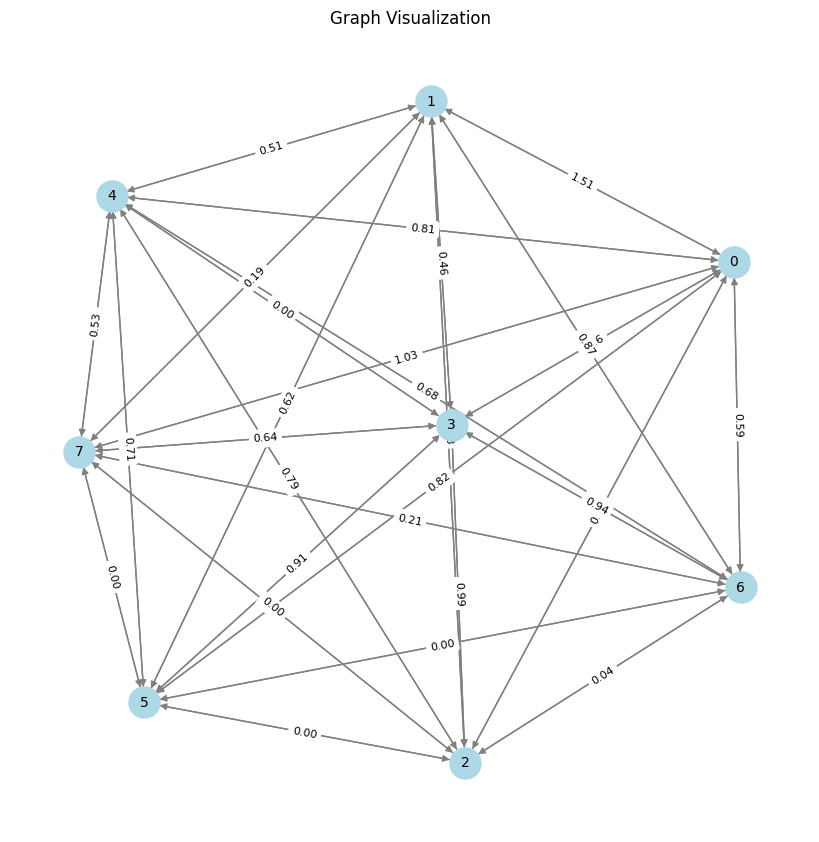

In [13]:
import networkx as nx
from torch_geometric.utils import to_networkx
import matplotlib.pyplot as plt


def visualize_graph(graph):
    """
    Visualizes a PyTorch Geometric graph using NetworkX.

    Args:
        graph: PyTorch Geometric Data object.
    """
    # Convert PyTorch Geometric graph to NetworkX graph
    nx_graph = to_networkx(graph, edge_attrs=["edge_attr"])

    # Create a plot
    plt.figure(figsize=(8, 8))
    pos = nx.spring_layout(nx_graph)  # Node positions
    nx.draw(nx_graph, pos, with_labels=True, node_color="lightblue",
            edge_color="gray", node_size=500, font_size=10)

    # Add edge labels (distance attributes)
    edge_labels = nx.get_edge_attributes(nx_graph, "edge_attr")
    edge_labels = {k: f"{v[2]:.2f}" for k,
                   v in edge_labels.items()}  # Format distances
    nx.draw_networkx_edge_labels(
        nx_graph, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Graph Visualization")
    plt.show()


# Visualize the first graph in the dataset
visualize_graph(graphs_dataset[0])

## 4. Graph Neural Network (GNN) Design

### Architecture
1. **Graph Attention Network (GAT)**:
   - Processes the graph structure and learns relationships between nodes using attention mechanisms.
   - Incorporates edge features (e.g., distances) into the learning process.

2. **Multi-Layer Perceptron (MLP)**:
   - Takes the aggregated graph embeddings and additional features (e.g., robot's heading) as input.
   - Produces the final risk prediction as output.

### Implementation Steps
1. Create a PyTorch module for the GNN.
2. Use PyTorch Geometric's `GATConv` for the GAT layers.
3. Concatenate the robot's heading (`cos(theta)`, `sin(theta)`) to the GNN output before the MLP.
4. Use ReLU activations for non-linearity.

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_scatter import scatter_sum, scatter_softmax


class GCBFGraphNetwork(nn.Module):
    def __init__(self):
        """
        Initializes the GCBF-inspired GNN.

        Args:
            args: Configuration object with attributes like feature dimensions, number of layers, etc.
        """
        super(GCBFGraphNetwork, self).__init__()

        # Define input dimension for z_ij
        self.zij_dim = 11  # Node features (3 + 3) + Edge features (5)

        # MLP ψθ1: Encodes z_ij
        self.psi1 = nn.Sequential(
            nn.Linear(self.zij_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

        # MLP ψθ2: Computes attention weights
        self.psi2 = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)  # Attention weight is scalar
        )

        # MLP ψθ3: Transforms edge-specific messages
        self.psi3 = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

        # MLP ψθ4: Outputs final scalar (y_hat)
        self.psi4 = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )

    def forward(self, feats, edge_index, edge_attr, batch):
        """
        Forward pass for GNN.

        Args:
            feats: Node feature tensor [total_nodes, feature_dim].
            edge_index: Edge index tensor [2, num_edges].
            edge_attr: Edge attribute tensor [num_edges, edge_dim].
            batch: Batch index tensor [total_nodes].

        Returns:
            Tensor: Predicted scalar values for each graph in the batch.
        """
        # Step 1: Create z_ij = [v_i, v_j, e_ij] for each edge
        src, dst = edge_index  # source and destination node indices
        v_i = feats[src]  # Features of source nodes [num_edges, 3]
        v_j = feats[dst]  # Features of destination nodes [num_edges, 3]
        # edge_attr: [num_edges, 4]

        # Shape: [num_edges, zij_dim]
        z_ij = torch.cat([v_i, v_j, edge_attr], dim=1)
        # print("z_ij shape:", z_ij.shape)

        # Step 2: Encode z_ij features via ψθ1
        q_ij = self.psi1(z_ij)  # Shape: [num_edges, 128]

        # Step 3: node-wise softmax !!
        # print("psi2 shape:", self.psi2(q_ij).shape)  # [num_edges, 1]
        raw_weights = self.psi2(q_ij).squeeze(-1)  # Shape: [num_edges]
        attention_weights = scatter_softmax(
            raw_weights, src)  # Shape: [num_edges]
        # print("attention_weights shape:", attention_weights.shape)
        # sum_check = scatter_sum(attention_weights, src)
        # print("sum_check shape:", sum_check.shape)
        # print("sum_check:", sum_check)
        # print("attention_weights:", attention_weights)
        messages = self.psi3(q_ij)  # Shape: [num_edges, 128]

        # Step 4: Aggregate messages to compute q_i for each node
        weighted_messages = attention_weights.unsqueeze(-1) * \
            messages  # Shape: [num_edges, 128]

        # print("weighted_messages shape:", weighted_messages.shape)

        # It become total_nodes, not total_edges - Shape: [total_nodes, 128]
        # print("src shape:", src.shape) # [num_edges]
        q_i = scatter_sum(weighted_messages, src, dim=0)
        # print("q_i shape:", q_i.shape)
        # Step 6: Final regression via ψθ4
        # Assuming q_i has shape [total_nodes, 128] and batch has shape [total_nodes]
        robot_indices = torch.cat(
            (torch.tensor([0], device=batch.device), torch.where(torch.diff(batch))[0] + 1))

        # print("robot_indices shape:", robot_indices.shape)
        # print("robot_indices:", robot_indices)
        robot_q = q_i[robot_indices]  # Shape: [num_graphs, 128]

        # Step 5: Pass the robot's feature vector through ψθ4
        output = self.psi4(robot_q)  # Shape: [num_graphs, 1]

        return output

### Test Inference with Arbitrary Graph

In [15]:
from torch_geometric.loader import DataLoader
model = GCBFGraphNetwork()


# Wrap dataset into graph representations
graphs_dataset = wrap_dataset_to_graphs(dataset)
# Create a DataLoader for batching
data_loader = DataLoader(graphs_dataset, batch_size=2, shuffle=True)

for sample_batch in data_loader:
    sample_batch = sample_batch
    print("Batch node features (x):", sample_batch.x)
    print("Batch edge index:", sample_batch.edge_index)
    print("Batch edge attributes (edge_attr):", sample_batch.edge_attr)
    print("Batch target (y):", sample_batch.y)
    print("Batch mapping (sample_batch):", sample_batch.batch)
    break

Batch node features (x): tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.]])
Batch edge index: tensor([[ 0,  0,  0,  1,  1,  1,  2,  2,  2,  3,  3,  3,  4,  4,  4,  4,  4,  4,
          5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  7,  7,  7,  7,  7,  7,
          8,  8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9, 10, 10, 10, 10, 10, 10],
        [ 1,  2,  3,  0,  2,  3,  0,  1,  3,  0,  1,  2,  5,  6,  7,  8,  9, 10,
          4,  6,  7,  8,  9, 10,  4,  5,  7,  8,  9, 10,  4,  5,  6,  8,  9, 10,
          4,  5,  6,  7,  9, 10,  4,  5,  6,  7,  8, 10,  4,  5,  6,  7,  8,  9]])
Batch edge attributes (edge_attr): tensor([[ 0.4586,  1.1667,  0.9363, -0.8184, -0.5746],
        [ 0.2228,  0.2356,  0.1030, -0.8184, -0.5746],
        [ 1.3590,  0.9585,  1.3193, -0.8184, -0.5746],
        [-0.4586, -1.1667

In [16]:
graph = sample_batch

# Perform a forward pass through the GNN
model.eval()  # Set the model to evaluation mode
with torch.no_grad():  # Disable gradient computations for testing
    output = model(graph.x, graph.edge_index,
                   graph.edge_attr, graph.batch)

# Print the output
print("batch :", graph.batch)
print("GNN Output (Predicted Risk):\n", output)

batch : tensor([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1])
GNN Output (Predicted Risk):
 tensor([[0.0327],
        [0.0335]])


## 5. Training the GNN
- Define the training process, including loss function and optimizer.
- Train the GNN on the dataset to predict risk levels.

In [17]:
import torch
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

# Define the dataset loader


def create_dataloader(graphs_dataset, batch_size=32):
    """
    Creates a DataLoader for batching graphs.
    Args:
        graphs_dataset (list): List of graph objects with targets (risk).
        batch_size (int): Batch size for training.
    Returns:
        DataLoader: A PyTorch Geometric DataLoader object.
    """
    return DataLoader(graphs_dataset, batch_size=batch_size, shuffle=True)  # FIXME:

In [18]:

# Loss function
criterion = nn.MSELoss()  # Mean Squared Error for regression

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train-test split
train_dataset, test_dataset = train_test_split(
    graphs_dataset, test_size=0.2, random_state=42)
# DataLoader
batch_size = 32
train_loader = create_dataloader(train_dataset, batch_size=batch_size)
test_loader = create_dataloader(test_dataset, batch_size=batch_size)

In [19]:
num_epochs = 300
model.train()  # Set the model to training mode

for epoch in range(num_epochs):
    # Training phase
    model.train()
    epoch_loss = 0.0
    for batch_idx, batch in enumerate(train_loader):
        # Extract batch data
        x = batch.x
        edge_index = batch.edge_index
        edge_attr = batch.edge_attr
        y = batch.y
        # print(y)
        # print(y.shape)
        batch_vec = batch.batch  # [total_nodes]

        # Forward pass
        predictions = model(x, edge_index, edge_attr, batch_vec)

        # Compute loss
        # print(predictions.shape)
        # print(y.shape)
        # TODO: be careful with the dimension. Might need to squeeze, if y is a scalar\
        # in this case, y : [num_batch], predictions: [num_batch, 1]
        # if, y : [num_batch, 2], and predictions: [num_batch, 2], then no need to squeeze
        loss = criterion(predictions.squeeze(1), y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate training loss
        epoch_loss += loss.item()

        # ------------------------------------------------------------------------------------
        # Optional: Visualize the FIRST graph in THIS batch (comment/uncomment to debug)
        # if batch_idx == 0:  # only do this for the first batch in the epoch
        #     sample_dict = parse_first_graph_in_batch(x, batch_vec, y)
        #     visualize_robot_and_obstacles(sample_dict)

        # break  # if you only want to visualize one batch and skip the rest for speed
        # ------------------------------------------------------------------------------------

    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in test_loader:
            # Extract batch data
            x = batch.x
            edge_index = batch.edge_index
            edge_attr = batch.edge_attr
            y = batch.y  # [batch_size, 1]
            batch_vec = batch.batch  # [total_nodes]

            # Forward pass
            predictions = model(x, edge_index, edge_attr, batch_vec)

            # Compute validation loss
            loss = criterion(predictions.squeeze(1), y)
            val_loss += loss.item()

    # Print epoch results
    print(
        f"Epoch {epoch + 1}/{num_epochs}, Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}")

Epoch 1/300, Train Loss: 23.3383, Val Loss: 4.3424
Epoch 2/300, Train Loss: 13.9588, Val Loss: 2.9258
Epoch 3/300, Train Loss: 9.2799, Val Loss: 1.9301
Epoch 4/300, Train Loss: 6.8644, Val Loss: 1.5656
Epoch 5/300, Train Loss: 6.9737, Val Loss: 1.3669
Epoch 6/300, Train Loss: 6.4657, Val Loss: 1.6141
Epoch 7/300, Train Loss: 6.1785, Val Loss: 1.8446
Epoch 8/300, Train Loss: 5.3251, Val Loss: 1.1173
Epoch 9/300, Train Loss: 4.9506, Val Loss: 1.1163
Epoch 10/300, Train Loss: 4.3932, Val Loss: 0.6271
Epoch 11/300, Train Loss: 5.0047, Val Loss: 1.4196
Epoch 12/300, Train Loss: 4.1578, Val Loss: 0.6104
Epoch 13/300, Train Loss: 6.7969, Val Loss: 0.9783
Epoch 14/300, Train Loss: 4.1071, Val Loss: 1.3505
Epoch 15/300, Train Loss: 4.1824, Val Loss: 1.5406
Epoch 16/300, Train Loss: 3.5686, Val Loss: 0.6177
Epoch 17/300, Train Loss: 3.1545, Val Loss: 0.7627
Epoch 18/300, Train Loss: 3.3557, Val Loss: 1.2159
Epoch 19/300, Train Loss: 4.2103, Val Loss: 1.1102
Epoch 20/300, Train Loss: 3.3810, Val 

## 6. Evaluation and Visualization
- Evaluate the model on a validation set.
- Visualize predictions for specific examples.

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def evaluate_model(model, val_loader):
    """
    Evaluates the model on the validation set.

    Args:
        model: The trained GNN model.
        val_loader: DataLoader for the validation set.

    Returns:
        dict: Dictionary containing MSE, MAE, and R^2 metrics.
    """
    model.eval()  # Set the model to evaluation mode
    predictions = []
    targets = []

    with torch.no_grad():  # Disable gradient computations
        for batch in val_loader:
            x = batch.x
            edge_index = batch.edge_index
            edge_attr = batch.edge_attr
            y = batch.y
            batch_vec = batch.batch

            # Forward pass
            preds = model(x, edge_index, edge_attr, batch_vec)

            # # Debug tensor shapes and types
            # print("Predictions shape:", preds.shape)
            # print("Targets shape:", y.shape)
            # print("Type of predictions:", type(preds))
            # print("Type of targets:", type(y))

            predictions.append(preds.detach().cpu().tolist())
            targets.append(y.detach().cpu().tolist())

    # Flatten predictions and targets
    predictions = np.concatenate(predictions, axis=0)
    targets = np.concatenate(targets, axis=0)

    # Compute metrics
    mse = mean_squared_error(targets, predictions)
    mae = mean_absolute_error(targets, predictions)
    r2 = r2_score(targets, predictions)

    return {"MSE": mse, "MAE": mae, "R^2": r2}


# Example: Evaluate the model on a validation set
val_metrics = evaluate_model(model, test_loader)
print("Validation Metrics:", val_metrics)

Validation Metrics: {'MSE': 0.028476041652982856, 'MAE': 0.06693648369905228, 'R^2': 0.9190633615175982}


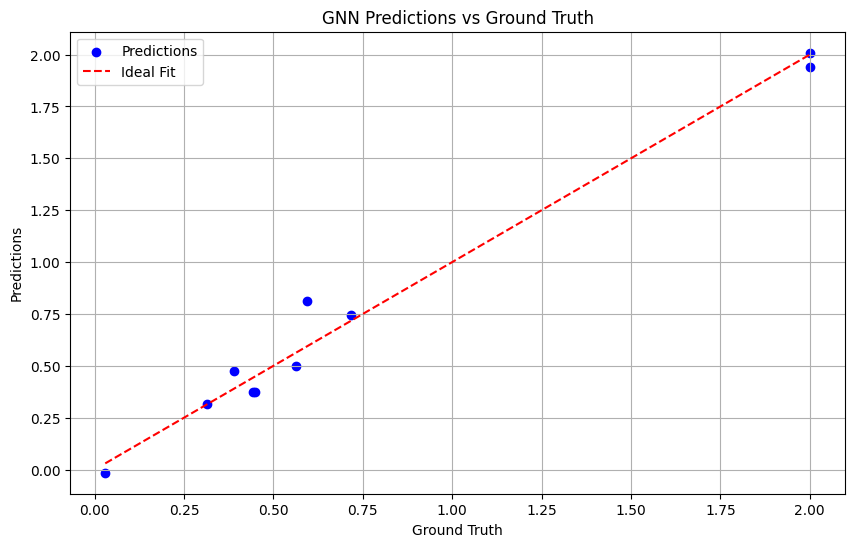

GCBFGraphNetwork(
  (psi1): Sequential(
    (0): Linear(in_features=11, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
  )
  (psi2): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
  (psi3): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
  )
  (psi4): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=1, bias=True)
  )
)


In [21]:
import matplotlib.pyplot as plt


def visualize_gnn_predictions(test_loader, model, num_samples=10):
    """
    Visualizes GNN predictions versus ground truth for specific examples.

    Args:
        test_loader: DataLoader for the test set.
        model: The trained GNN model.
        num_samples (int): Number of samples to visualize.
    """
    model.eval()
    predictions = []
    ground_truths = []

    with torch.no_grad():
        for batch in test_loader:
            x = batch.x
            edge_index = batch.edge_index
            edge_attr = batch.edge_attr
            y = batch.y
            batch_vec = batch.batch

            # Forward pass
            preds = model(x, edge_index, edge_attr, batch_vec)

            # Collect predictions and ground truths
            predictions.extend(preds.detach().cpu().tolist())
            ground_truths.extend(y.detach().cpu().tolist())

            # Stop after collecting the required number of samples
            if len(predictions) >= num_samples:
                break

    # Visualization: Plot predictions vs ground truth
    plt.figure(figsize=(10, 6))
    plt.scatter(ground_truths[:num_samples],
                predictions[:num_samples], c='blue', label="Predictions")
    plt.plot([min(ground_truths), max(ground_truths)], [min(ground_truths), max(
        ground_truths)], color='red', linestyle='--', label="Ideal Fit")
    plt.title("GNN Predictions vs Ground Truth")
    plt.xlabel("Ground Truth")
    plt.ylabel("Predictions")
    plt.legend()
    plt.grid()
    plt.show()

    print(model)


# Example: Visualize GNN predictions
visualize_gnn_predictions(test_loader, model)